# PyTorch Primer for Keras Users: MNIST CNN Side-by-Side

This notebook is chapter **00** of the GenAI learning track -- a primer to run _before_
`01-rnns/`. The chapters ahead mix TensorFlow/Keras and PyTorch notebooks (see
`01-rnns/MIT/TF_Part1_Intro-keras.ipynb` vs. `PT_Part1_Intro.ipynb`), so if you know Keras
well but haven't written raw PyTorch before, this closes that gap with the smallest useful
example: **the same CNN digit classifier, built twice, cell by cell.**

**How to use this notebook:** each section has a short explanation, then a **Keras cell**
immediately followed by the **equivalent PyTorch cell**, doing the exact same job. Run them
in order -- by the end you'll have two independently trained models on the same MNIST data.

## What you'll build

A small convolutional network for MNIST digit classification, in both frameworks:

```
Conv2D(32, 3x3) -> MaxPool(2x2) -> Conv2D(64, 3x3) -> MaxPool(2x2) -> Flatten -> Dense(128) -> Dense(10)
```

## What you'll be able to do when done

- Translate a Keras `Sequential` model into a PyTorch `nn.Module` and back
- Explain the five biggest structural differences between the two frameworks (see the
  cheat-sheet at the end)
- Write a PyTorch training loop from scratch, instead of relying on `model.fit()`
- Know the channel-order (NHWC vs. NCHW), device-placement, and train/eval-mode gotchas that
  trip up Keras users switching to PyTorch


## Section 1: Imports & Seeding

**Keras:** TensorFlow is the backend; `tf.random.set_seed` plus `np.random.seed` covers
reproducibility. TensorFlow 2.x runs eagerly by default -- no separate "graph mode" step
needed to run the cells below.

**PyTorch:** There's no framework-level "backend" -- `torch` _is_ the library you import
directly. Reproducibility is one call: `torch.manual_seed`. PyTorch is eager by default too,
but unlike Keras there is no automatic device placement: you will see explicit `.to(device)`
calls throughout this notebook, because tensors and models don't move to a GPU unless you
tell them to.


In [1]:
# --- Keras ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available (Keras):", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.21.0
GPU available (Keras): False


In [2]:
# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device (PyTorch):", device)

PyTorch version: 2.12.1+cpu
Device (PyTorch): cpu


## Section 2: Loading MNIST

**Keras:** `keras.datasets.mnist` hands you plain NumPy arrays -- `(x_train, y_train),
(x_test, y_test)` -- already split into train/test. No `Dataset`/`DataLoader` concept; you
pass the arrays straight into `model.fit()` later.

**PyTorch:** there's no bundled dataset module as convenient as `keras.datasets`; instead
`torchvision.datasets.MNIST` downloads and wraps the data as a `Dataset`, and you wrap _that_
in a `DataLoader` to get batching, shuffling, and iteration for free. This two-layer
abstraction (`Dataset` + `DataLoader`) is the PyTorch-native way to feed data to a training
loop, and you'll see it reused for any custom dataset later in this track.


In [3]:
# --- Keras ---
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add the channel dimension LAST -> shape (N, 28, 28, 1)
x_train = np.expand_dims(x_train.astype("float32") / 255.0, -1)
x_test = np.expand_dims(x_test.astype("float32") / 255.0, -1)

print("x_train:", x_train.shape, "| y_train:", y_train.shape)
print("x_test: ", x_test.shape, " | y_test: ", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28, 1) | y_train: (60000,)
x_test:  (10000, 28, 28, 1)  | y_test:  (10000,)


In [ ]:
# --- PyTorch ---
# ToTensor() scales to [0, 1] AND puts the channel dimension FIRST -> shape (1, 28, 28)
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# .data is the raw, untransformed tensor (no channel dim yet); indexing the dataset applies
# `transform` and is what the DataLoader actually feeds the model, so that's the shape that matters.
sample_image, sample_label = train_dataset[0]
print(
    "train_dataset:",
    len(train_dataset),
    "images | one transformed sample:",
    sample_image.shape,
)
print("test_dataset: ", len(test_dataset), "images")

train_dataset: 60000 images | one transformed sample: torch.Size([1, 28, 28])
test_dataset:  10000 images


### The gotcha you'll hit immediately: NHWC vs. NCHW

Look closely at the two shapes printed above: Keras gave you `(28, 28, 1)` per image
(**channels last**), PyTorch gave you `(1, 28, 28)` (**channels first**). This isn't a typo
-- it's a real, silent bug magnet. If you ever port a Keras preprocessing pipeline to
PyTorch (or vice versa) and forget to transpose, your convolution will either crash on a
shape mismatch or, worse, silently run on the wrong axis. `torchvision.transforms.ToTensor()`
already does this conversion for you, which is exactly why it's used above instead of a raw
NumPy-to-tensor cast.


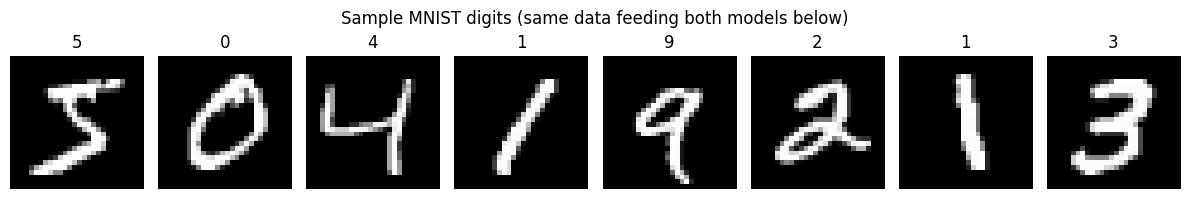

In [6]:
# Shared visualization -- both frameworks are looking at the same underlying MNIST digits
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample MNIST digits (same data feeding both models below)")
plt.tight_layout()
plt.show()

## Section 3: Defining the Model

**Keras:** `keras.Sequential` lists layers in order. You only need to declare the _input_
shape once (via `keras.Input`); every layer after that infers its input size automatically
-- including the flattened size going into the first `Dense` layer.

**PyTorch:** a model is a Python class that subclasses `nn.Module`. You declare every layer
in `__init__` (each with an explicit `in_channels`/`in_features`) and then write the
**forward pass yourself** as ordinary Python code in `forward()`. Nothing is inferred: the
comment below shows the exact arithmetic for why `64 * 5 * 5` is the flattened size feeding
`fc1` -- get this number wrong and you get a shape-mismatch error at the first `forward()`
call, not at model-definition time.


In [ ]:
# --- Keras ---
keras_model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
# --- PyTorch ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # 28 -> conv3x3 -> 26 -> pool2 -> 13 -> conv3x3 -> 11 -> pool2 -> 5 (floor)
        # so the flattened feature map is 64 channels x 5 x 5 = 1600 -- computed BY HAND,
        # not inferred, which is the single biggest day-to-day difference from Keras.
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten every dim except the batch dim
        x = F.relu(self.fc1(x))
        return self.fc2(
            x
        )  # raw logits -- softmax is applied inside the loss function later


pytorch_model = SimpleCNN().to(device)

### Inspecting the model

**Keras:** `.summary()` prints a layer-by-layer shape and parameter table for free.

**PyTorch:** `print(model)` shows the module tree (no shapes, since shapes aren't known
until you actually run data through it), so parameter counting is usually a one-line
generator expression over `model.parameters()`.


In [9]:
# --- Keras ---
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- PyTorch ---
print(pytorch_model)

n_params = sum(p.numel() for p in pytorch_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {n_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 225,034


## Section 4: Compile vs. Loss + Optimizer

**Keras:** `model.compile()` bundles the optimizer, loss function, and metrics into the
model object itself -- `model.fit()` will read all three from there.

**PyTorch:** there is no `compile()` step. The loss function and optimizer are just plain
objects you create and hold onto yourself; nothing is attached to the model. You are
responsible for using them correctly inside the training loop in the next section.


In [11]:
# --- Keras ---
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # labels are plain ints, not one-hot
    metrics=["accuracy"],
)

In [ ]:
# --- PyTorch ---
criterion = (
    nn.CrossEntropyLoss()
)  # combines log-softmax + negative-log-likelihood in one call
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=1e-3)

## Section 5: Training

This is the single biggest difference between the two frameworks.

**Keras:** `model.fit()` hides the entire training loop -- batching, the forward pass, the
backward pass, the optimizer step, and metric tracking are all handled internally.

**PyTorch:** there is no `.fit()`. You write the loop over epochs and batches yourself.
Four lines are doing all the actual learning, and Keras users almost always forget the
first one at least once:

1. `optimizer.zero_grad()` -- **gradients accumulate by default in PyTorch**; if you don't
   clear them, every batch adds its gradient on top of the last one.
2. `outputs = model(images)` -- the forward pass (calls your `forward()` method).
3. `loss.backward()` -- computes gradients for every parameter via autograd.
4. `optimizer.step()` -- applies the update using those gradients.


In [13]:
# --- Keras ---
history = keras_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=3,
    validation_split=0.1,
)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9348 - loss: 0.2227 - val_accuracy: 0.9810 - val_loss: 0.0651
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9807 - loss: 0.0641 - val_accuracy: 0.9873 - val_loss: 0.0455
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9866 - loss: 0.0428 - val_accuracy: 0.9878 - val_loss: 0.0414


In [14]:
# --- PyTorch ---
EPOCHS = 3
pytorch_model.train()  # switch to training mode (matters once you add dropout/batchnorm)

for epoch in range(EPOCHS):
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # (1) clear gradients from the previous batch
        outputs = pytorch_model(images)  # (2) forward pass
        loss = criterion(outputs, labels)
        loss.backward()  # (3) backward pass -- populates .grad on every parameter
        optimizer.step()  # (4) apply the update

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - loss: {running_loss / total:.4f} - "
        f"accuracy: {correct / total:.4f}"
    )

Epoch 1/3 - loss: 0.2693 - accuracy: 0.9214
Epoch 2/3 - loss: 0.0677 - accuracy: 0.9790
Epoch 3/3 - loss: 0.0453 - accuracy: 0.9860


## Section 6: Evaluation

**Keras:** `model.evaluate()` runs the test set through the compiled loss/metrics for you.

**PyTorch:** another manual loop -- but with two additions that are easy to forget coming
from Keras:

- `model.eval()` switches off training-only behavior (dropout, batchnorm statistics).
- `with torch.no_grad():` disables gradient tracking, which both saves memory and speeds up
  inference, since you're not going to call `.backward()` during evaluation.


In [15]:
# --- Keras ---
test_loss, test_acc = keras_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} - Test accuracy: {test_acc:.4f}")

Test loss: 0.0395 - Test accuracy: 0.9865


In [16]:
# --- PyTorch ---
pytorch_model.eval()  # switch to eval mode
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():  # no gradients needed for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = pytorch_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

print(f"Test loss: {test_loss / total:.4f} - Test accuracy: {correct / total:.4f}")

Test loss: 0.0369 - Test accuracy: 0.9873


## Section 7: Inference / Prediction

**Keras:** `model.predict()` runs the forward pass and returns probabilities (because the
final layer already has a `softmax` activation).

**PyTorch:** you call the model directly like a function -- `model(x)` -- inside
`torch.no_grad()`, and since `forward()` returns raw logits (no `softmax` inside the model,
remember `CrossEntropyLoss` applied it implicitly during training), `argmax` on the logits
is enough to get the predicted class; you don't need `softmax` for this unless you want the
actual probabilities to display.


In [17]:
# --- Keras ---
sample_x, sample_y = x_test[:8], y_test[:8]
probs = keras_model.predict(sample_x, verbose=0)
pred_labels = probs.argmax(axis=1)

print("True:      ", sample_y.tolist())
print("Predicted: ", pred_labels.tolist())

True:       [7, 2, 1, 0, 4, 1, 4, 9]
Predicted:  [7, 2, 1, 0, 4, 1, 4, 9]


In [18]:
# --- PyTorch ---
pytorch_model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images, sample_labels = sample_images[:8].to(device), sample_labels[:8]

with torch.no_grad():
    logits = pytorch_model(sample_images)
    pred_labels = logits.argmax(dim=1).cpu()

print("True:      ", sample_labels.tolist())
print("Predicted: ", pred_labels.tolist())

True:       [7, 2, 1, 0, 4, 1, 4, 9]
Predicted:  [7, 2, 1, 0, 4, 1, 4, 9]


## Cheat Sheet: Keras -> PyTorch

| Keras concept                                                  | PyTorch equivalent                                                                                      |
| -------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| `keras.Sequential([...])`                                      | `class Model(nn.Module)` with layers in `__init__` + logic in `forward()`                               |
| Automatic input-shape inference                                | You compute and hard-code every layer's input size yourself                                             |
| `Dense(units)`                                                 | `nn.Linear(in_features, out_features)`                                                                  |
| `Conv2D(filters, kernel_size)`                                 | `nn.Conv2d(in_channels, out_channels, kernel_size)`                                                     |
| `MaxPooling2D(pool_size)`                                      | `nn.MaxPool2d(kernel_size)`                                                                             |
| `Flatten()`                                                    | `x.view(x.size(0), -1)` or `nn.Flatten()`                                                               |
| Data as NumPy arrays, shape `(N, H, W, C)` (**channels last**) | `Dataset` + `DataLoader`, shape `(N, C, H, W)` (**channels first**)                                     |
| `model.compile(optimizer=..., loss=..., metrics=...)`          | Create `criterion` and `optimizer` as separate objects; no `compile()` step                             |
| `model.fit(x, y, epochs=...)`                                  | Write the training loop yourself: `zero_grad()` -> forward -> `backward()` -> `step()`                  |
| `model.evaluate(x, y)`                                         | Manual loop with `model.eval()` + `torch.no_grad()`                                                     |
| `model.predict(x)`                                             | `model(x)` inside `torch.no_grad()`, after `model.eval()`                                               |
| `model.summary()`                                              | `print(model)` + manual `sum(p.numel() for p in model.parameters())`                                    |
| GPU used automatically if present                              | Explicit `.to(device)` on both the model and every batch of data                                        |
| Final `Dense(10, activation="softmax")`                        | Final `nn.Linear(..., 10)` returns raw logits; `nn.CrossEntropyLoss` applies the log-softmax internally |

## Gotchas worth remembering

1. **Gradients accumulate.** Forgetting `optimizer.zero_grad()` silently corrupts training --
   there's no error, just worse accuracy.
2. **`model.train()` / `model.eval()` matter.** Any layer that behaves differently at train
   vs. inference time (dropout, batchnorm) needs the mode set explicitly, every time you
   switch between training and evaluating.
3. **`torch.no_grad()` isn't optional for eval/inference.** Skipping it still _works_, but
   wastes memory tracking gradients you'll never use.
4. **Channels-first, not channels-last.** `(C, H, W)`, not `(H, W, C)`. This is the #1 shape-mismatch
   bug when porting data pipelines between the two frameworks.
5. **Nothing moves to the GPU for you.** Both the model (`model.to(device)`) and every batch
   of data (`images.to(device)`) need an explicit `.to(device)` call.
6. **No automatic shape inference.** You compute conv-output and flatten sizes by hand (or
   use `nn.LazyLinear`/`nn.AdaptiveAvgPool2d` to sidestep it) -- Keras never makes you do this.

## Next steps

Head to [`01-rnns/`](../01-rnns/) next -- it has the same PyTorch-vs-Keras pairing
(`PT_Part1_Intro.ipynb` and `TF_Part1_Intro-keras.ipynb`), now applied to recurrent networks
instead of a CNN. Everything in this primer's cheat sheet applies there too.
